# RPS Territorial Walkers — Random Spawn

This notebook uses the shared walker/space dynamics. The only scenario-specific change is random spawning on an initially empty grid.

## Model and Rules

Each time step: every walker takes exactly one nearest-neighbor step (up/down/left/right), with periodic boundaries by default.

If a walker enters a destination cell:
1. Empty: destination becomes walker species.
2. Same species: no conflict.
3. Different species: apply RPS rule, convert both old and destination cells to winner, and update walker species to winner.

## Algorithm Plan

Pseudocode:

```text
initialize_grid_and_walkers(N, walkers_each_species, seed):
    grid <- zeros(N,N)
    create walkers with species [1,1,2,2,3,3] for debug case
    place on distinct random cells
    set grid at those cells to species

winner(a,b):
    return RPS winner

step_walker(walker, grid):
    choose random move from four directions
    apply periodic wrap
    inspect destination and update by rules

step_system(grid, walkers):
    process walkers in random order

run_simulation(...):
    iterate time steps
    store species fractions and optional snapshots
```

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

EMPTY, ROCK, PAPER, SCISSORS = 0, 1, 2, 3
BASE_UPSET_CAPTURE_PROB = 0.025

STATE_COLORS = {
    EMPTY: "#f0f0f0",
    ROCK: "#000000",
    PAPER: "#0095DA",
    SCISSORS: "#86ff23"
}
STATE_NAMES = {
    EMPTY: "Empty",
    ROCK: "Rock",
    PAPER: "Paper",
    SCISSORS: "Scissors"
}

cmap = ListedColormap([STATE_COLORS[s] for s in [EMPTY, ROCK, PAPER, SCISSORS]])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

In [85]:
def winner(a, b):
    if a == b:
        return a
    if {a, b} == {ROCK, SCISSORS}:
        return ROCK
    if {a, b} == {SCISSORS, PAPER}:
        return SCISSORS
    if {a, b} == {PAPER, ROCK}:
        return PAPER
    raise ValueError(f"Invalid species pair: {a}, {b}")

def local_species_counts(walkers, n, m):
    counts = np.zeros((n, m, 4), dtype=np.int32)
    for w in walkers:
        counts[w["x"], w["y"], w["species"]] += 1
    return counts

def against_flow_capture_probability(attacker_count, defender_count, base_prob=BASE_UPSET_CAPTURE_PROB):
    advantage = max(0, int(attacker_count) - int(defender_count))
    return min(1.0, base_prob * advantage)

def step_system(grid, walkers, rng, periodic=True, flow_win_prob=1.0):
    n, m = grid.shape
    cell_counts = local_species_counts(walkers, n, m)
    moves = np.array([(-1, 0), (1, 0), (0, -1), (0, 1)], dtype=np.int8)

    for i in rng.permutation(len(walkers)):
        w = walkers[i]
        x_old, y_old = w["x"], w["y"]
        species = int(w["species"])

        dx, dy = moves[rng.integers(0, 4)]
        x_new, y_new = x_old + int(dx), y_old + int(dy)

        if periodic:
            x_new %= n
            y_new %= m
        else:
            if not (0 <= x_new < n and 0 <= y_new < m):
                continue

        cell_counts[x_old, y_old, species] = max(0, cell_counts[x_old, y_old, species] - 1)

        destination = int(grid[x_new, y_new])
        final_species = species

        if destination == EMPTY:
            grid[x_new, y_new] = species
        elif destination != species:
            normal_winner = winner(species, destination)
            attacker_count = int(cell_counts[x_new, y_new, species]) + 1
            defender_count = int(cell_counts[x_new, y_new, destination])

            if normal_winner == species:
                conflict_winner = species if rng.random() < flow_win_prob else destination
            else:
                p_upset = against_flow_capture_probability(attacker_count, defender_count)
                conflict_winner = species if rng.random() < p_upset else destination

            grid[x_old, y_old] = conflict_winner
            grid[x_new, y_new] = conflict_winner
            final_species = int(conflict_winner)

        w["x"], w["y"], w["species"] = x_new, y_new, int(final_species)
        cell_counts[x_new, y_new, int(final_species)] += 1

def detect_takeover(grid):
    u = np.unique(grid)
    if len(u) == 1 and u[0] in (ROCK, PAPER, SCISSORS):
        return True, int(u[0])
    return False, None

def draw_color_key(ax_key):
    ax_key.axis("off")
    ax_key.set_title("Color key", fontsize=11)
    key_states = [ROCK, PAPER, SCISSORS, EMPTY]
    y0, dy = 0.82, 0.18
    for i, s in enumerate(key_states):
        y = y0 - i * dy
        ax_key.add_patch(
            plt.Rectangle(
                (0.08, y - 0.045),
                0.22,
                0.09,
                facecolor=STATE_COLORS[s],
                edgecolor="black",
                transform=ax_key.transAxes,
                clip_on=False,
            )
        )
        ax_key.text(
            0.36,
            y,
            f"{STATE_NAMES[s]} ({s})",
            transform=ax_key.transAxes,
            va="center",
            fontsize=10,
        )

def show_grid(grid, title="Grid"):
    fig, (ax, ax_key) = plt.subplots(
        1, 2, figsize=(8, 6), gridspec_kw={"width_ratios": [1.0, 0.42]}
    )
    ax.imshow(grid, cmap=cmap, norm=norm, origin="lower", interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    draw_color_key(ax_key)
    fig.tight_layout()
    plt.show()

In [86]:
# Scenario-specific setup: RANDOM SPAWN on empty space
def setup_random_spawn(n=80, walkers_each_species=200, seed=0):
    rng = np.random.default_rng(seed)
    grid = np.zeros((n, n), dtype=np.int8)

    species_list = ([ROCK] * walkers_each_species +
                    [PAPER] * walkers_each_species +
                    [SCISSORS] * walkers_each_species)

    total_walkers = len(species_list)
    if total_walkers > n * n:
        raise ValueError("Too many walkers for grid size.")

    picks = rng.choice(n * n, size=total_walkers, replace=False)
    walkers = []
    for sp, pos in zip(species_list, picks):
        x, y = divmod(int(pos), n)
        walkers.append({"x": x, "y": y, "species": int(sp)})
        grid[x, y] = int(sp)

    return grid, walkers, rng

def run_random_trial(n=80, walkers_each_species=200, steps=1000, seed=0, periodic=True, frame_skip=20):
    grid, walkers, rng = setup_random_spawn(n=n, walkers_each_species=walkers_each_species, seed=seed)
    frames = [grid.copy()]
    takeover_step, winner_species = None, None

    for t in range(1, steps + 1):
        step_system(grid, walkers, rng, periodic=periodic, flow_win_prob=1.0)
        if (t % frame_skip) == 0:
            frames.append(grid.copy())
        done, ws = detect_takeover(grid)
        if done:
            takeover_step, winner_species = t, ws
            if (t % frame_skip) != 0:
                frames.append(grid.copy())
            break

    return {
        "grid": grid,
        "walkers": walkers,
        "frames": frames,
        "takeover_step": takeover_step,
        "winner_species": winner_species
    }

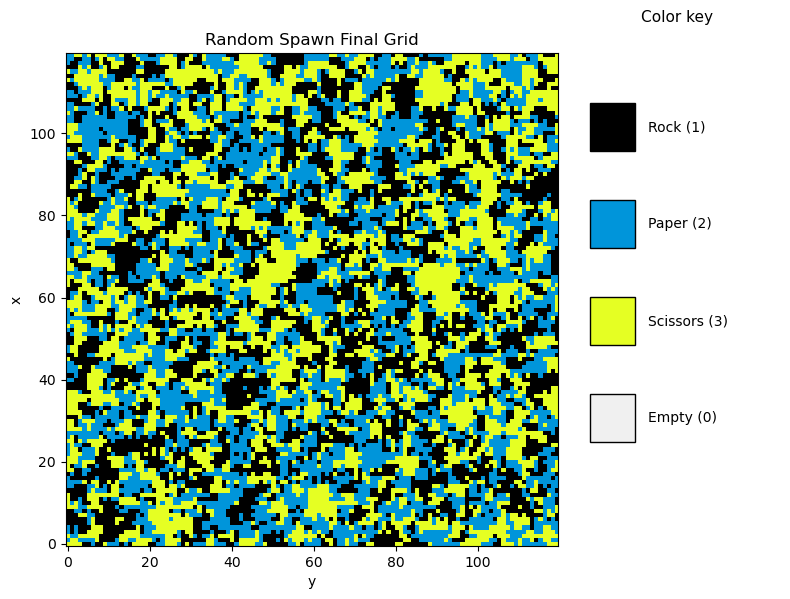

{'takeover_step': None, 'winner': None, 'num_walkers': 1500, 'num_saved_frames': 151}


In [87]:
result = run_random_trial(n=120, walkers_each_species=500, steps=1500, seed=42, periodic=True, frame_skip=10)
show_grid(result["grid"], title="Random Spawn Final Grid")
print({
    "takeover_step": result["takeover_step"],
    "winner": None if result["winner_species"] is None else STATE_NAMES[result["winner_species"]],
    "num_walkers": len(result["walkers"]),
    "num_saved_frames": len(result["frames"])
})

In [88]:
from pathlib import Path
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, Image, display

def render_frames_gif_and_html(frames, gif_name="random_spawn.gif", fps=12):
    if not frames:
        raise ValueError("No frames available to animate.")

    gif_path = Path.cwd() / gif_name

    fig, (ax, ax_key) = plt.subplots(
        1, 2, figsize=(8, 6), gridspec_kw={"width_ratios": [1.0, 0.42]}
    )
    im = ax.imshow(frames[0], cmap=cmap, norm=norm, origin="lower", interpolation="nearest")
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    draw_color_key(ax_key)

    def update(i):
        im.set_data(frames[i])
        ax.set_title(f"Random Spawn (frame {i+1}/{len(frames)})")
        return [im]

    ani = FuncAnimation(fig, update, frames=len(frames), interval=1000 / fps, blit=False)
    ani.save(gif_path, writer=PillowWriter(fps=fps))
    html_anim = ani.to_jshtml(fps=fps)
    plt.close(fig)

    display(HTML(html_anim))
    display(Image(filename=str(gif_path)))

    print(f"Saved GIF: {gif_path}")
    print("Rendered embedded HTML animation.")

### JC: I know they start off in random places given different seeds, and they sem to be in equillibrium but im gonna test under what conditions does dominance of one faction happen. I should try decreasing the size of the grid so theres less space to occupy

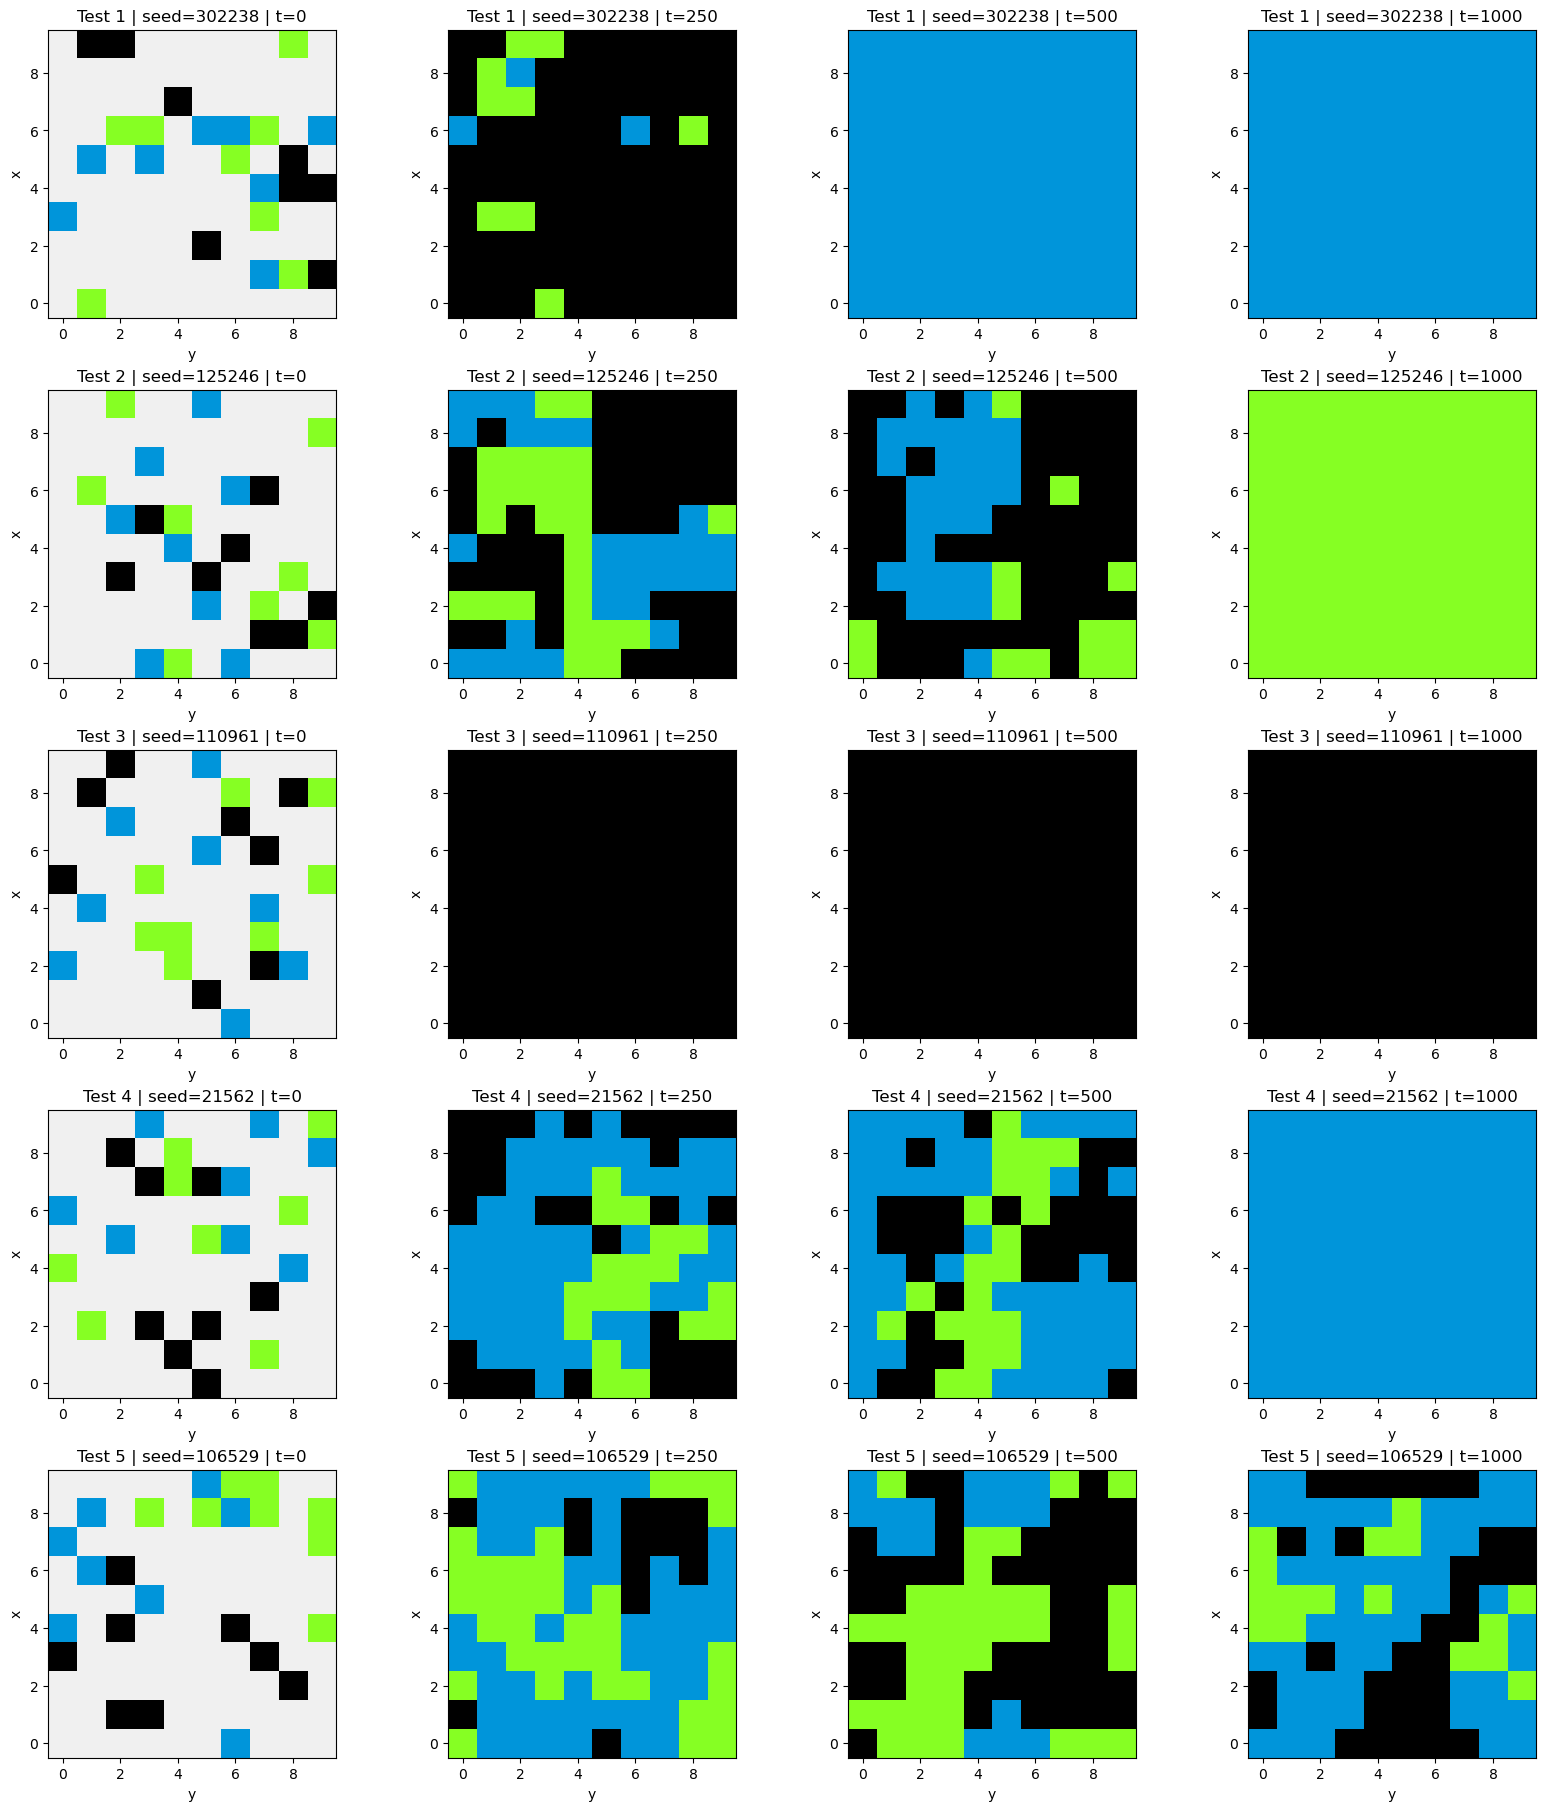

Saved single PNG: /Users/joshuaclavecillas/anaconda_projects/Computational_folder/rps_debug_5tests_1_image.png


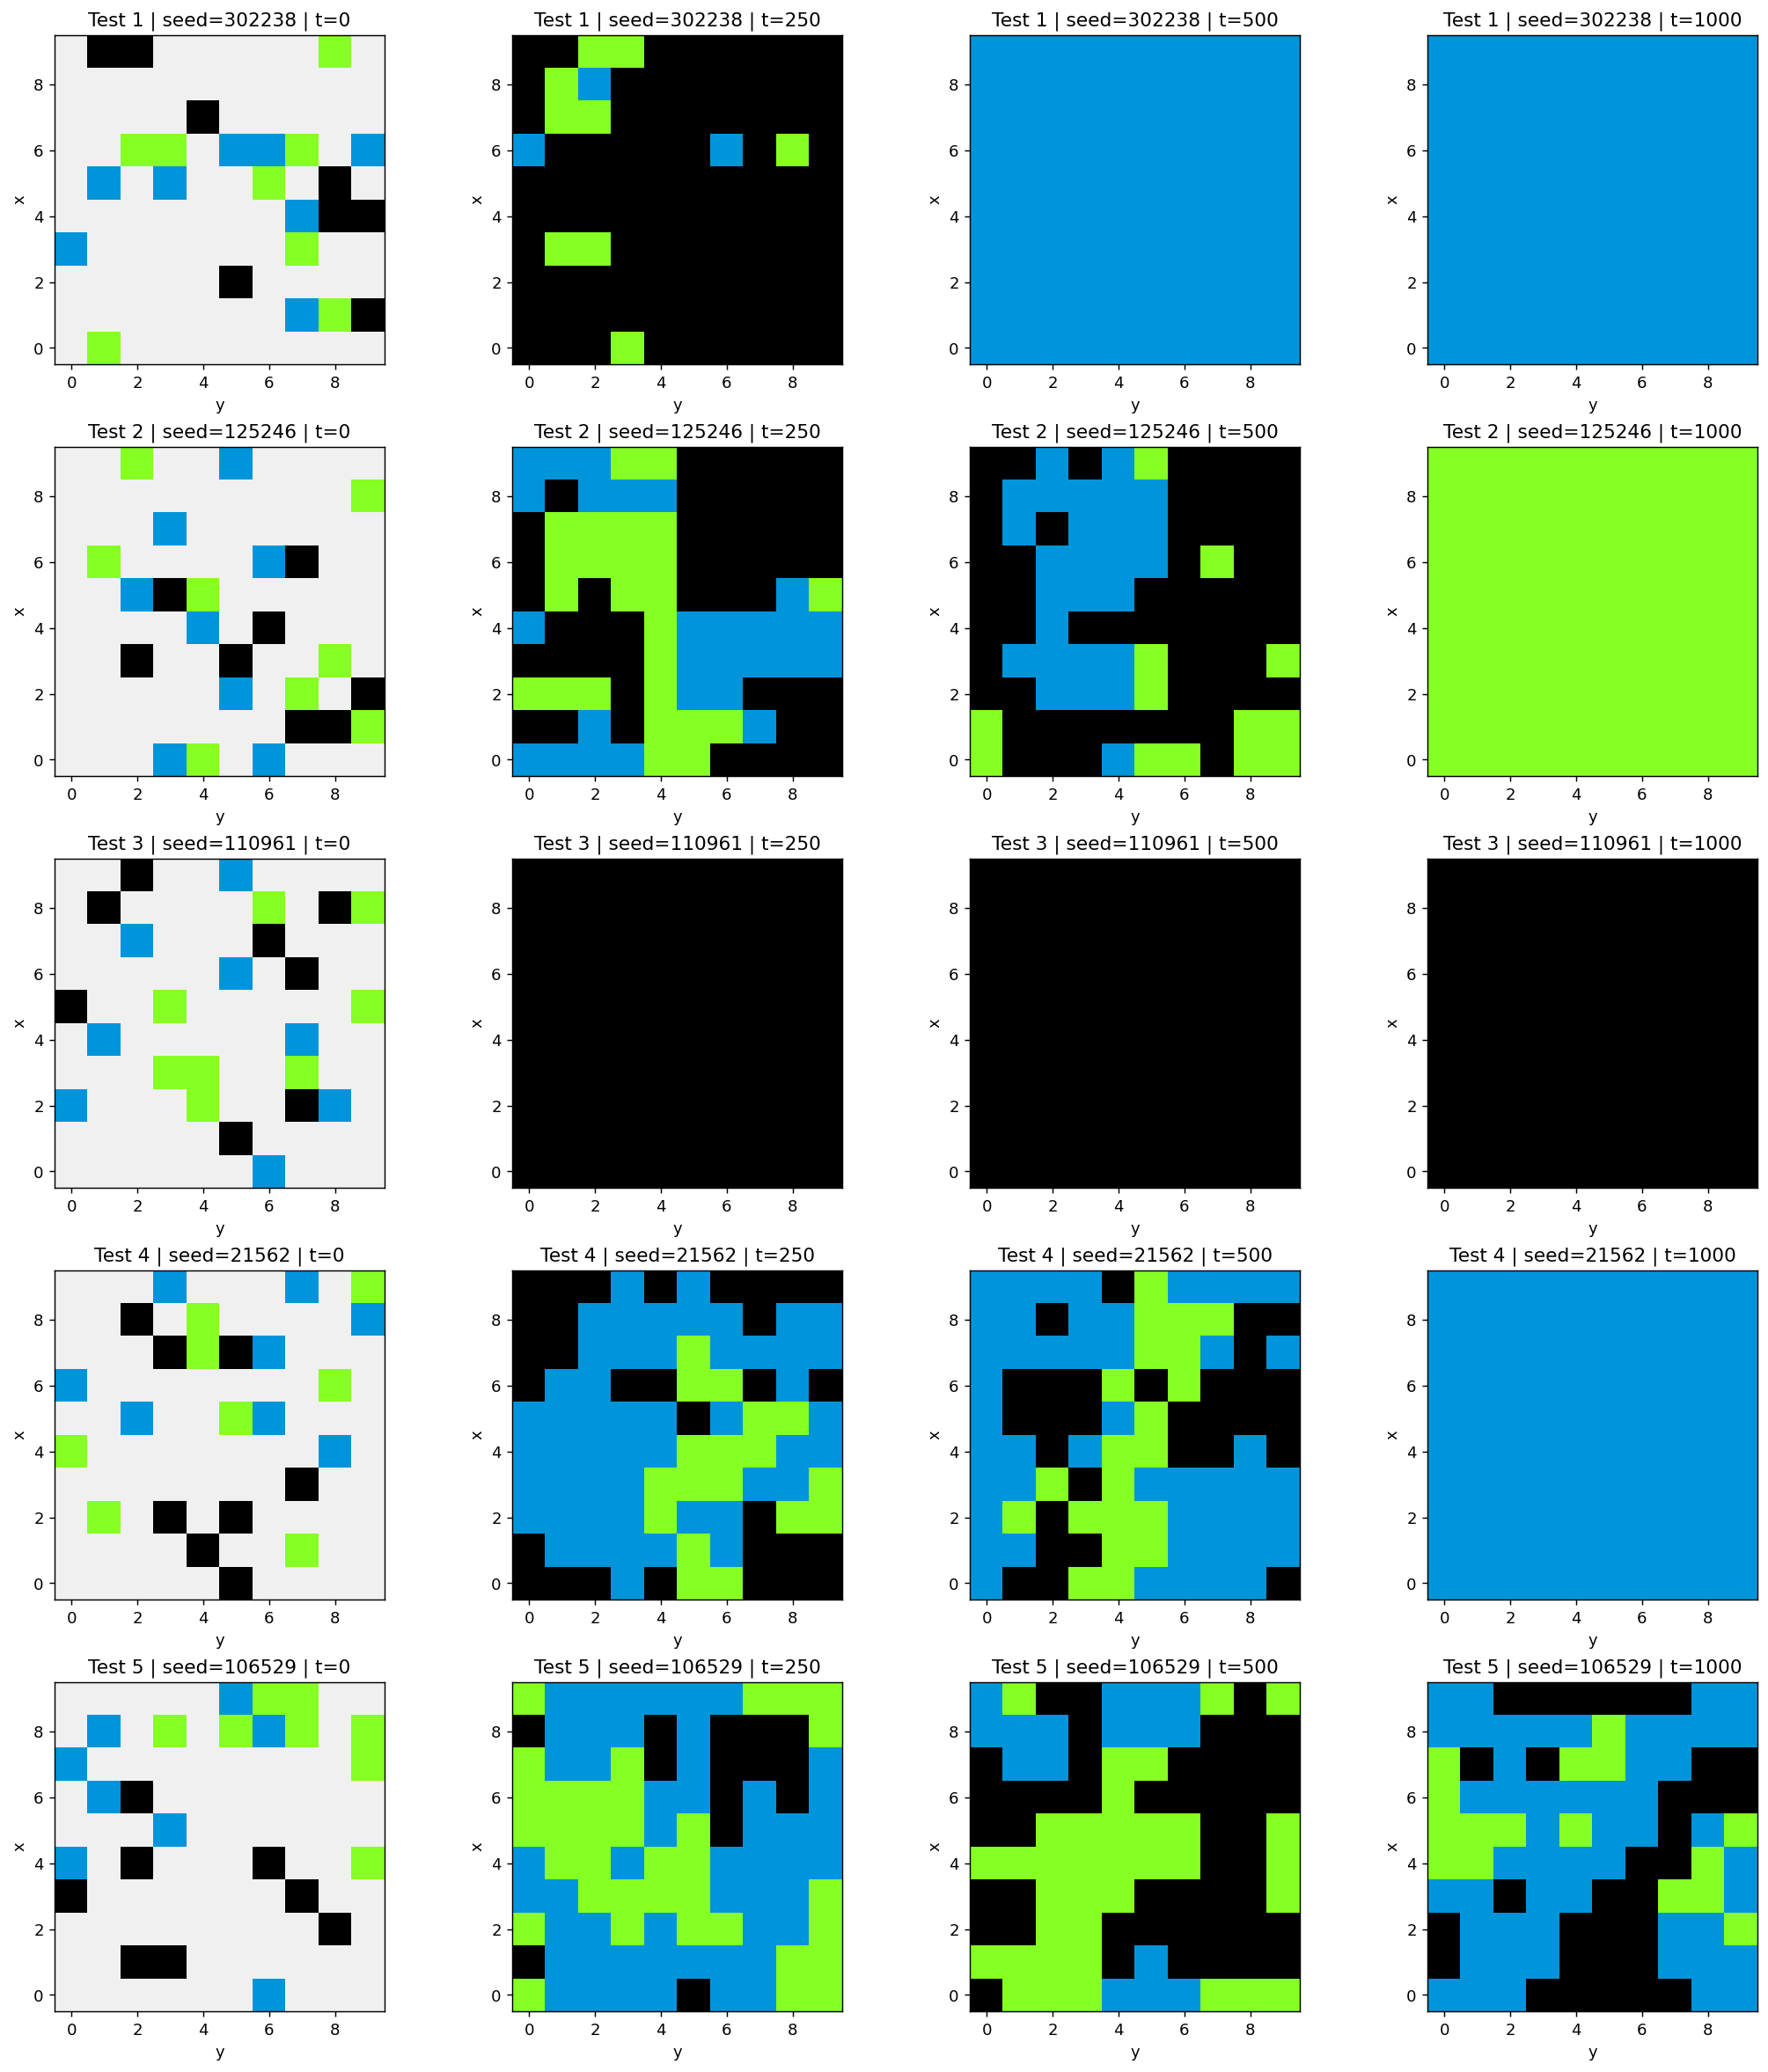

In [99]:
# Debug case: 10x10, 5 tests with separate seeds, saved as one compressed PNG
from pathlib import Path
from IPython.display import Image, display

steps_test_1 = 1000
snapshot_times = [0, int(steps_test_1 / 4), int(steps_test_1 / 2), steps_test_1]

seed_rng = np.random.default_rng()
test_seeds = seed_rng.integers(1, 1_000_000, size=5).tolist()

def run_debug_snapshots(n, walkers_each_species, steps, seed, snapshot_times, periodic=True):
    grid, walkers, rng = setup_random_spawn(
        n=n,
        walkers_each_species=walkers_each_species,
        seed=int(seed),
    )

    snapshot_times = sorted(set(snapshot_times))
    snapshots = {}

    if 0 in snapshot_times:
        snapshots[0] = grid.copy()

    for t in range(1, steps + 1):
        step_system(grid, walkers, rng, periodic=periodic, flow_win_prob=1.0)
        if t in snapshot_times:
            snapshots[t] = grid.copy()

    return snapshots

all_snapshots = []
for seed in test_seeds:
    s_dbg = run_debug_snapshots(
        n=10,
        walkers_each_species=8,
        steps=steps_test_1,
        seed=seed,
        snapshot_times=snapshot_times,
        periodic=True,
    )
    all_snapshots.append(s_dbg)

fig, axes = plt.subplots(len(test_seeds), len(snapshot_times), figsize=(16, 18), constrained_layout=True)

for row, (seed, s_dbg) in enumerate(zip(test_seeds, all_snapshots)):
    for col, t in enumerate(snapshot_times):
        ax = axes[row, col]
        ax.imshow(s_dbg[t], cmap=cmap, norm=norm, origin="lower", interpolation="nearest")
        ax.set_title(f"Test {row+1} | seed={seed} | t={t}")
        ax.set_xlabel("y")
        ax.set_ylabel("x")

png_path = Path.cwd() / "rps_debug_5tests_1_image.png"
try:
    fig.savefig(png_path, dpi=130, bbox_inches="tight", pil_kwargs={"optimize": True, "compress_level": 9})
except TypeError:
    fig.savefig(png_path, dpi=130, bbox_inches="tight")

plt.show()
print(f"Saved single PNG: {png_path}")
display(Image(filename=str(png_path)))

### JC: After many iterations of this and experimenting I found that at large steps and a smaller size grid with a size of 10x10 and a starting population of 8 for each faction it goes to domination of a single faction. At larger grid size or lower population there is a drop off in percentage where one faction dominates. I should probably try to mess around with initial population bias in a medium grid size.

n=15, walkers=90, steps=3000, trials per setting=17
(Every trial used a different random seed.)

Initial probs (R,P,S)=(0.3333333333333333, 0.3333333333333333, 0.3333333333333333)
  Favored faction: Rock
  Strict takeover rate: 0.35
  Near-takeover rate (>= 100%): 0.35
  Avg dominant share: 0.659
  Dominant-at-end counts: {'Rock': 6, 'Paper': 5, 'Scissors': 6}
  Example seeds used: [354576093, 995837257, 849837368]

Initial probs (R,P,S)=(0.5, 0.25, 0.25)
  Favored faction: Rock
  Strict takeover rate: 0.24
  Near-takeover rate (>= 100%): 0.24
  Avg dominant share: 0.594
  Dominant-at-end counts: {'Rock': 6, 'Paper': 3, 'Scissors': 8}
  Example seeds used: [109215923, 864721752, 338798083]

Initial probs (R,P,S)=(0.25, 0.5, 0.25)
  Favored faction: Paper
  Strict takeover rate: 0.18
  Near-takeover rate (>= 100%): 0.18
  Avg dominant share: 0.555
  Dominant-at-end counts: {'Rock': 8, 'Paper': 7, 'Scissors': 2}
  Example seeds used: [948226058, 984217995, 403784872]

Initial probs (R,P,

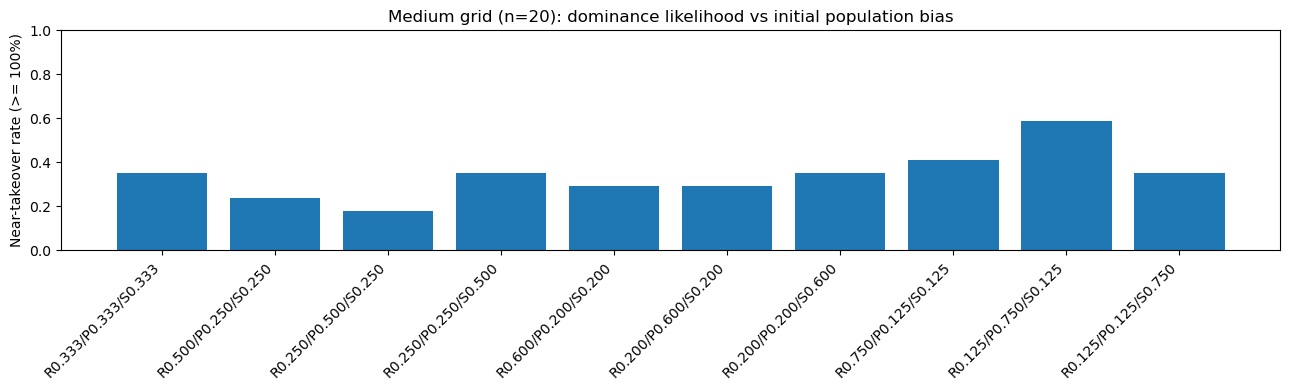

In [90]:
# Medium-grid bias exploration: n=20, distinct random seed per trial
n_med = 15
steps_med = 3000
total_walkers_med = 90
trials_per_setting = 17
near_takeover_threshold = 1.0

# Each tuple is (p_rock, p_paper, p_scissors)
bias_settings = [
    (1/3, 1/3, 1/3),
    (0.50, 0.25, 0.25),
    (0.25, 0.50, 0.25),
    (0.25, 0.25, 0.50),
    (0.60, 0.20, 0.20),
    (0.20, 0.60, 0.20),
    (0.20, 0.20, 0.60),
    (0.75, 0.125, 0.125),
    (0.125, 0.75, 0.125),
    (0.125, 0.125, 0.75),
]


def setup_random_spawn_biased_medium(n, total_walkers, probs, seed):
    rng = np.random.default_rng(int(seed))
    probs = np.array(probs, dtype=float)
    probs = probs / probs.sum()

    counts = rng.multinomial(total_walkers, probs)
    species = np.array([ROCK, PAPER, SCISSORS], dtype=np.int8)

    grid = np.zeros((n, n), dtype=np.int8)
    picks = rng.choice(n * n, size=total_walkers, replace=False)

    walkers = []
    offset = 0
    for sp, c in zip(species, counts):
        for pos in picks[offset:offset + c]:
            x, y = divmod(int(pos), n)
            walkers.append({"x": x, "y": y, "species": int(sp)})
            grid[x, y] = int(sp)
        offset += c

    rng.shuffle(walkers)
    return grid, walkers, rng, counts


def run_biased_trial_medium(n, total_walkers, probs, steps, seed):
    grid, walkers, rng, init_counts = setup_random_spawn_biased_medium(
        n=n,
        total_walkers=total_walkers,
        probs=probs,
        seed=seed,
    )

    takeover_step, takeover_species = None, None

    for t in range(1, steps + 1):
        step_system(grid, walkers, rng, periodic=True, flow_win_prob=1.0)
        done, ws = detect_takeover(grid)
        if done:
            takeover_step, takeover_species = t, ws
            break

    final_counts = {
        ROCK: int(np.sum(grid == ROCK)),
        PAPER: int(np.sum(grid == PAPER)),
        SCISSORS: int(np.sum(grid == SCISSORS)),
    }
    species_total = sum(final_counts.values())
    dominant_species = max(final_counts, key=final_counts.get)
    dominant_share = (final_counts[dominant_species] / species_total) if species_total > 0 else 0.0

    return {
        "seed": int(seed),
        "init_counts": {
            ROCK: int(init_counts[0]),
            PAPER: int(init_counts[1]),
            SCISSORS: int(init_counts[2]),
        },
        "takeover": takeover_species is not None,
        "takeover_species": takeover_species,
        "takeover_step": takeover_step,
        "dominant_species": dominant_species,
        "dominant_share": float(dominant_share),
        "final_counts": final_counts,
    }


seed_rng = np.random.default_rng()
seed_pool = seed_rng.integers(1, 1_000_000_000, size=len(bias_settings) * trials_per_setting)
seed_iter = iter(seed_pool.tolist())

all_rows = []
for probs in bias_settings:
    for _ in range(trials_per_setting):
        seed = next(seed_iter)
        trial = run_biased_trial_medium(
            n=n_med,
            total_walkers=total_walkers_med,
            probs=probs,
            steps=steps_med,
            seed=seed,
        )
        trial["probs"] = probs
        all_rows.append(trial)

print(f"n={n_med}, walkers={total_walkers_med}, steps={steps_med}, trials per setting={trials_per_setting}")
print("(Every trial used a different random seed.)\n")

for probs in bias_settings:
    rows = [r for r in all_rows if r["probs"] == probs]
    takeover_rate = np.mean([r["takeover"] for r in rows])
    near_takeover_rate = np.mean([r["dominant_share"] >= near_takeover_threshold for r in rows])

    win_counts = {ROCK: 0, PAPER: 0, SCISSORS: 0}
    for r in rows:
        win_counts[r["dominant_species"]] += 1

    avg_dom_share = float(np.mean([r["dominant_share"] for r in rows]))

    favored_idx = int(np.argmax(probs))
    favored_species = [ROCK, PAPER, SCISSORS][favored_idx]

    print(f"Initial probs (R,P,S)={probs}")
    print(f"  Favored faction: {STATE_NAMES[favored_species]}")
    print(f"  Strict takeover rate: {takeover_rate:.2f}")
    print(f"  Near-takeover rate (>= {near_takeover_threshold:.0%}): {near_takeover_rate:.2f}")
    print(f"  Avg dominant share: {avg_dom_share:.3f}")
    print("  Dominant-at-end counts:", {STATE_NAMES[k]: v for k, v in win_counts.items()})

    sample_seeds = [r["seed"] for r in rows[:3]]
    print(f"  Example seeds used: {sample_seeds}\n")

# Quick visual: near-takeover rate by initial bias setting
labels = [f"R{p[0]:.3f}/P{p[1]:.3f}/S{p[2]:.3f}" for p in bias_settings]
near_rates = [
    np.mean([r["dominant_share"] >= near_takeover_threshold for r in all_rows if r["probs"] == p])
    for p in bias_settings
]

plt.figure(figsize=(13, 4))
plt.bar(range(len(labels)), near_rates)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel(f"Near-takeover rate (>= {near_takeover_threshold:.0%})")
plt.title("Medium grid (n=20): dominance likelihood vs initial population bias")
plt.tight_layout()
plt.show()

### JC: I found that this wasnt too helpful visualizing the biases, maybe I should plot the fraction vs time of each faction in different seeds.

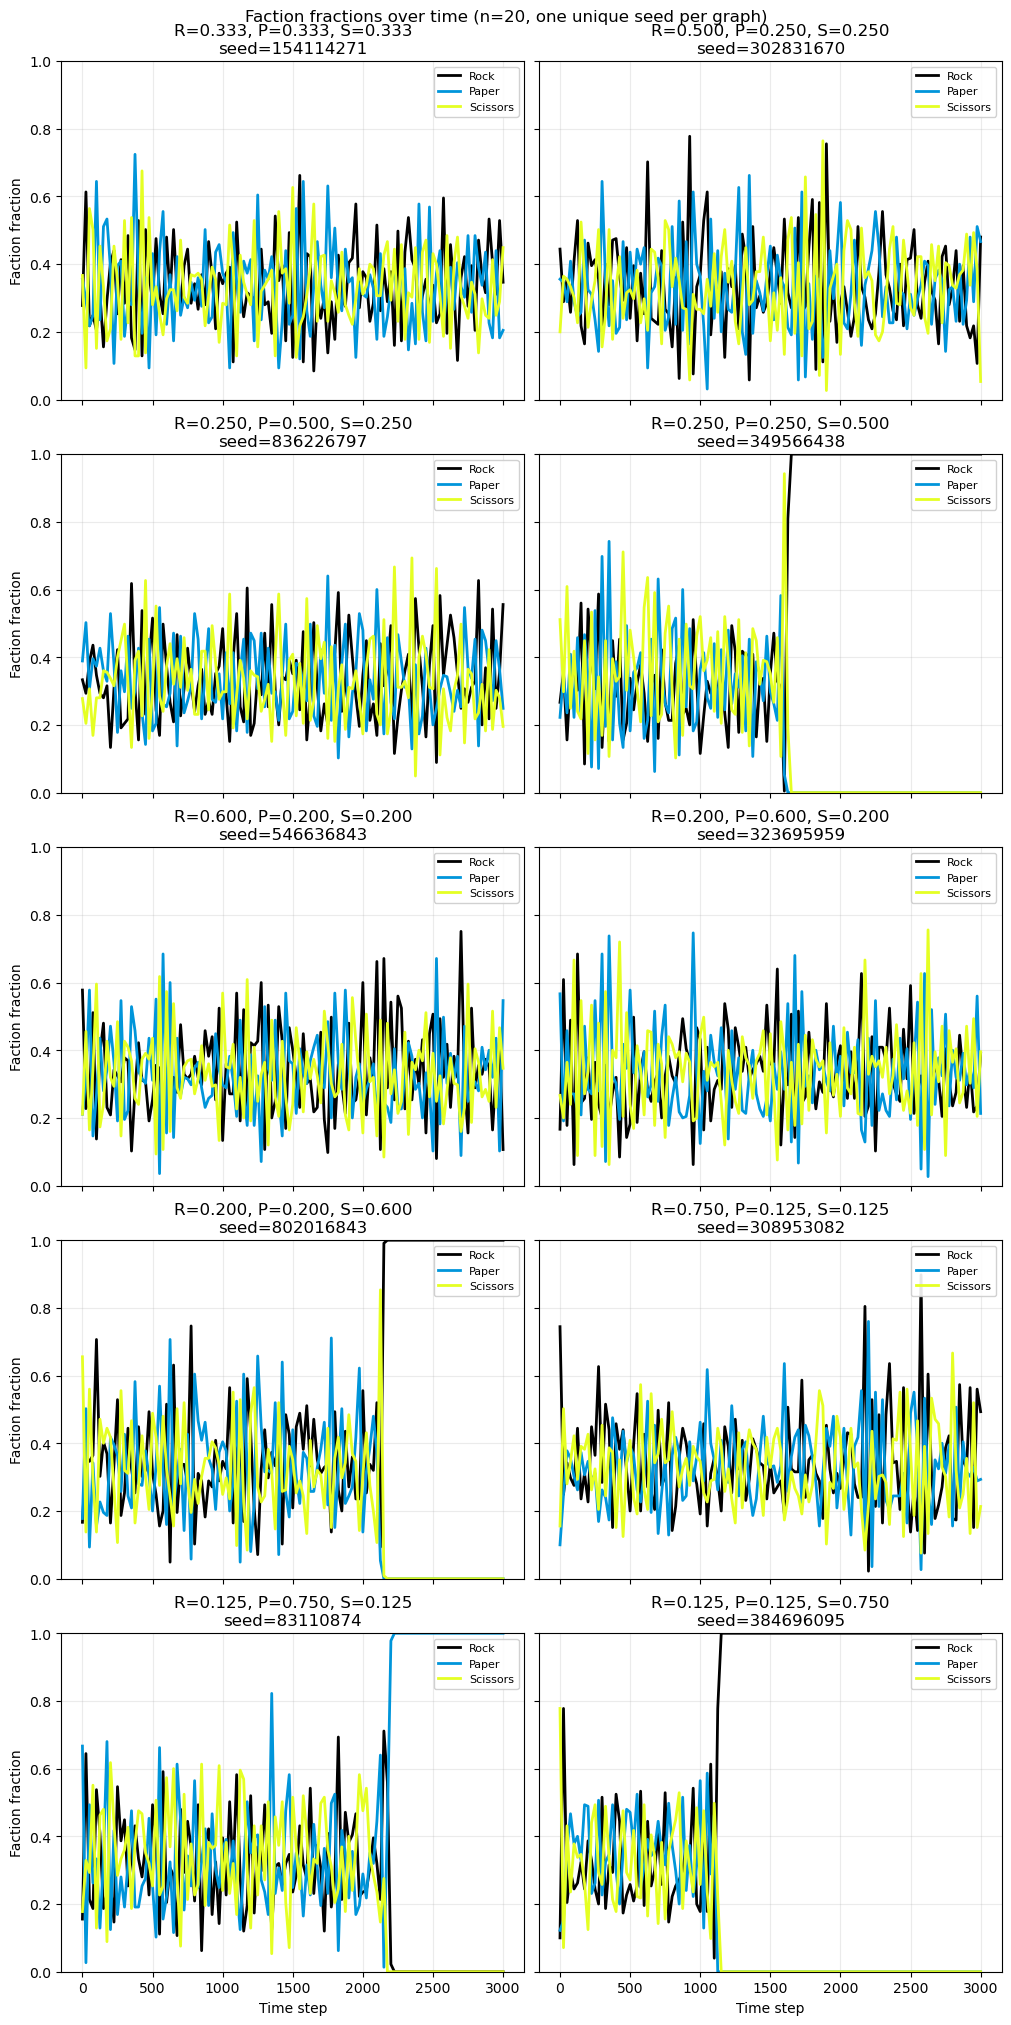

Unique seeds used (one per graph): [154114271, 302831670, 836226797, 349566438, 546636843, 323695959, 802016843, 308953082, 83110874, 384696095]


In [92]:
# Fraction-over-time plots (one graph per bias, 3 faction curves per graph)
n_plot = 15
steps_plot = 3000
total_walkers_plot = 90
sample_every = 25

bias_settings_plot = [
    (1/3, 1/3, 1/3),
    (0.50, 0.25, 0.25),
    (0.25, 0.50, 0.25),
    (0.25, 0.25, 0.50),
    (0.60, 0.20, 0.20),
    (0.20, 0.60, 0.20),
    (0.20, 0.20, 0.60),
    (0.75, 0.125, 0.125),
    (0.125, 0.75, 0.125),
    (0.125, 0.125, 0.75),
]


def setup_random_spawn_biased_ts(n, total_walkers, probs, seed):
    rng = np.random.default_rng(int(seed))
    probs = np.array(probs, dtype=float)
    probs = probs / probs.sum()

    counts = rng.multinomial(total_walkers, probs)
    species = np.array([ROCK, PAPER, SCISSORS], dtype=np.int8)

    grid = np.zeros((n, n), dtype=np.int8)
    picks = rng.choice(n * n, size=total_walkers, replace=False)

    walkers = []
    offset = 0
    for sp, c in zip(species, counts):
        for pos in picks[offset:offset + c]:
            x, y = divmod(int(pos), n)
            walkers.append({"x": x, "y": y, "species": int(sp)})
            grid[x, y] = int(sp)
        offset += c

    rng.shuffle(walkers)
    return grid, walkers, rng


def faction_fractions(grid):
    r = np.sum(grid == ROCK)
    p = np.sum(grid == PAPER)
    s = np.sum(grid == SCISSORS)
    total = r + p + s
    if total == 0:
        return 0.0, 0.0, 0.0
    return r / total, p / total, s / total


def run_fraction_trajectory(n, total_walkers, probs, steps, seed, sample_every=25):
    grid, walkers, rng = setup_random_spawn_biased_ts(
        n=n,
        total_walkers=total_walkers,
        probs=probs,
        seed=seed,
    )

    times = [0]
    fr = [faction_fractions(grid)]

    for t in range(1, steps + 1):
        step_system(grid, walkers, rng, periodic=True, flow_win_prob=1.0)
        if (t % sample_every == 0) or (t == steps):
            times.append(t)
            fr.append(faction_fractions(grid))

    fr = np.array(fr)
    return np.array(times), fr[:, 0], fr[:, 1], fr[:, 2]


seed_rng_plot = np.random.default_rng()
plot_seeds = seed_rng_plot.integers(1, 1_000_000_000, size=len(bias_settings_plot)).tolist()

fig, axes = plt.subplots(5, 2, figsize=(10, 20), sharex=True, sharey=True, constrained_layout=True)
axes = axes.ravel()

for i, (probs, seed) in enumerate(zip(bias_settings_plot, plot_seeds)):
    t, rock_f, paper_f, sciss_f = run_fraction_trajectory(
        n=n_plot,
        total_walkers=total_walkers_plot,
        probs=probs,
        steps=steps_plot,
        seed=seed,
        sample_every=sample_every,
    )

    ax = axes[i]
    ax.plot(t, rock_f, color=STATE_COLORS[ROCK], lw=2, label="Rock")
    ax.plot(t, paper_f, color=STATE_COLORS[PAPER], lw=2, label="Paper")
    ax.plot(t, sciss_f, color=STATE_COLORS[SCISSORS], lw=2, label="Scissors")
    ax.set_title(f"R={probs[0]:.3f}, P={probs[1]:.3f}, S={probs[2]:.3f}\nseed={seed}")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", fontsize=8, frameon=True, framealpha=0.9)
    if i % 2 == 0:
        ax.set_ylabel("Faction fraction")
    if i >= 8:
        ax.set_xlabel("Time step")

plt.suptitle("Faction fractions over time (n=20, one unique seed per graph)", y=1.005)
plt.show()

print("Unique seeds used (one per graph):", plot_seeds)